# Coordination Metrics Analysis - Symmetric Overcooked

This notebook analyzes coordination metrics between different LLM pairs in the Overcooked environment.
We'll examine how different model size combinations (14B, 32B, 8B, 4B, 1.7B) affect coordination patterns.


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Configure matplotlib
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


## 1. Data Loading and Preprocessing


In [56]:
# Load the data
df = pd.read_csv('sym_cooperative_actions_level_4.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (765, 10)

Columns: ['UID', 'p0', 'p1', 'recipe', 'p0_valid_actions', 'p1_valid_actions', 'p0_total_actions', 'p1_total_actions', 'free_ride_index', 'alternation_rate']

First few rows:


,UID,p0,p1,recipe,p0_valid_actions,p1_valid_actions,p0_total_actions,p1_total_actions,free_ride_index,alternation_rate
0,2025-08-27_02-06-41,Qwen3-14B,Qwen3-14B,sliced_eggplant_and_chickpea_stew,5,2,21,10,0.428571,0.50
1,2025-08-27_02-32-42,Qwen3-14B,Qwen3-14B,sliced_eggplant_and_chickpea_stew,6,5,15,14,0.090909,0.70
2,2025-08-27_03-22-39,Qwen3-14B,Qwen3-14B,sliced_eggplant_and_chickpea_stew,3,6,21,18,0.333333,0.50
3,2025-08-27_04-13-49,Qwen3-14B,Qwen3-14B,sliced_eggplant_and_chickpea_stew,1,2,8,9,0.333333,1.00
4,2025-08-27_04-29-19,Qwen3-14B,Qwen3-14B,sliced_eggplant_and_chickpea_stew,4,1,7,5,0.600000,0.25



Per-run metrics:


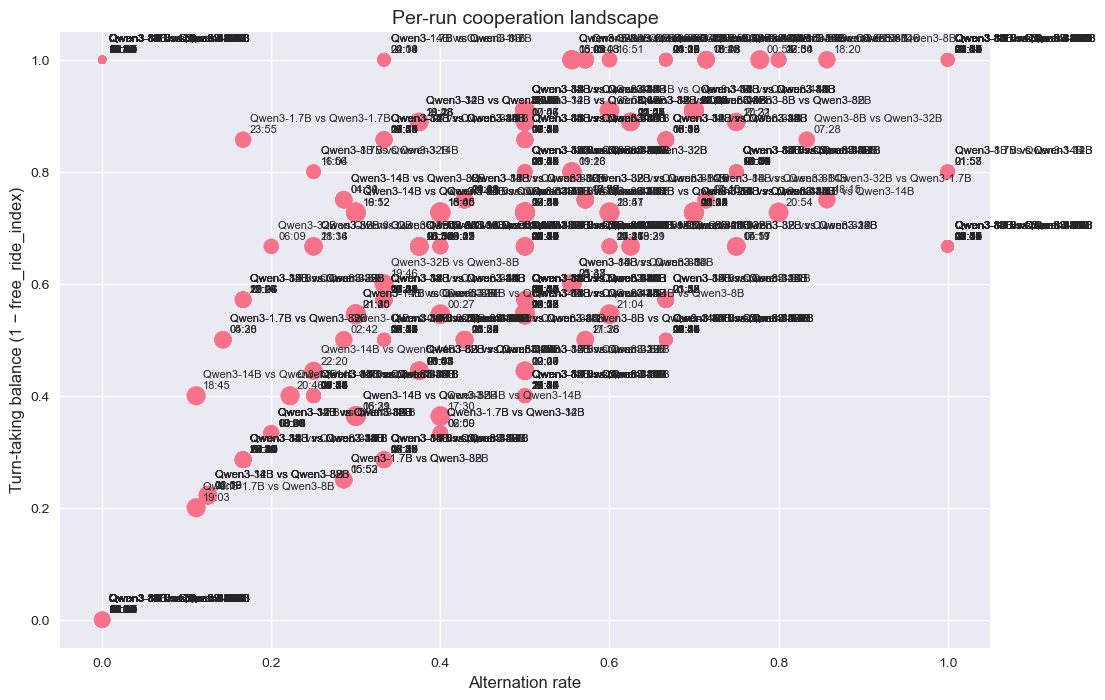

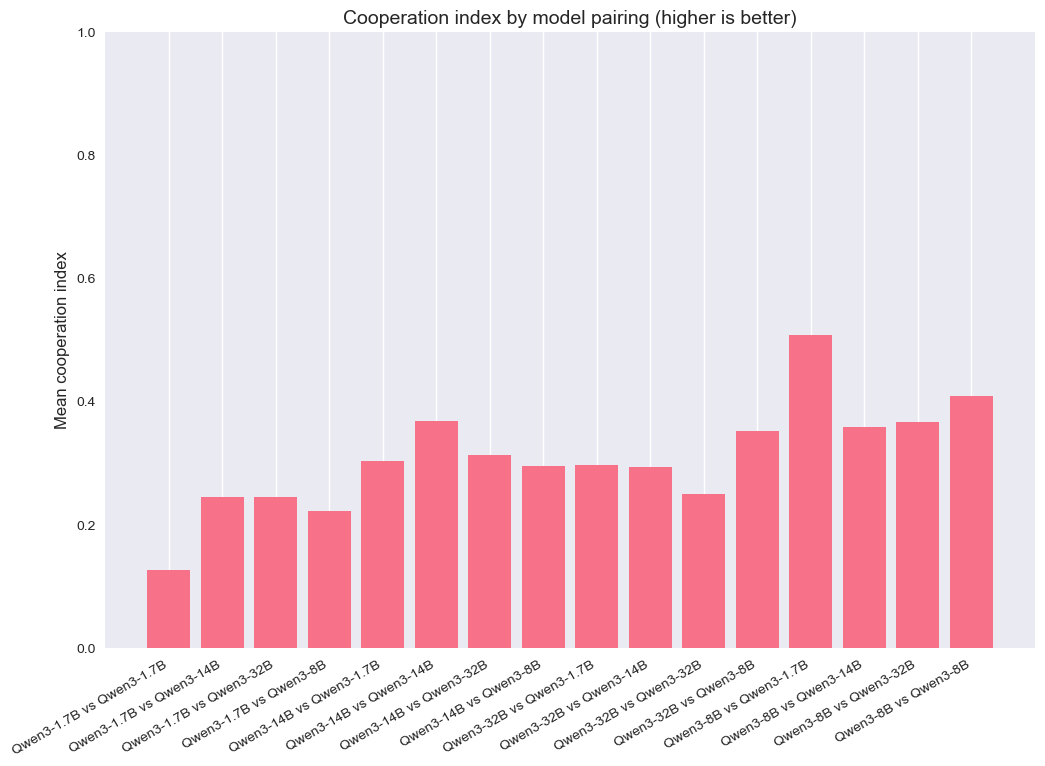

Top pairing by mean cooperation_index:
  Qwen3-8B vs Qwen3-1.7B
  mean_cooperation_index = 0.508
  mean_alternation = 0.562, mean_balance = 0.719
  valid contribution shares: p0 48.3% / p1 51.7%

Coordination modes (per run):
coordination_mode
mutual turn-taking            361
parallel / conflict-prone     212
batched but fair              172
alternating but imbalanced     20


In [57]:
# Self-contained analysis & visualization for cooperation metrics
#
# This cell:
# 1) Loads the provided CSV (embedded as a string).
# 2) Cleans and derives cooperation metrics.
# 3) Produces several informative plots (matplotlib only; one chart per figure).
# 4) Displays a summary table you can sort/filter (falls back to printing if a helper is unavailable).
#
# Key derived measures:
# - balance := 1 - free_ride_index  (closer to 1 => more evenly shared valid steps)
# - cooperation_index := alternation_rate * balance  (simple composite in [0,1])
# - coordination_mode := qualitative quadrant from (alternation_rate, balance)

import io
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Coerce numerics (missing values -> NaN)
num_cols = [
    "p0_valid_actions","p1_valid_actions","p0_total_actions","p1_total_actions",
    "free_ride_index","alternation_rate"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Derived columns
df["pair"] = df["p0"] + " vs " + df["p1"]
df["total_valid"] = df["p0_valid_actions"].fillna(0) + df["p1_valid_actions"].fillna(0)

# balance in [0,1], where 1 = perfectly balanced valid turns (free_ride_index=0)
df["balance"] = 1.0 - df["free_ride_index"].clip(lower=0, upper=1)

# Composite cooperation score (simple product, stays in [0,1])
df["cooperation_index"] = (df["alternation_rate"].clip(0,1) * df["balance"]).fillna(0.0)

# Qualitative quadrant
def mode_from(a, b):
    if pd.isna(a) or pd.isna(b):
        return "unknown"
    if a >= 0.5 and b >= 0.5:
        return "mutual turn-taking"
    if a >= 0.5 and b < 0.5:
        return "alternating but imbalanced"
    if a < 0.5 and b >= 0.5:
        return "batched but fair"
    return "parallel / conflict-prone"

df["coordination_mode"] = [mode_from(a, b) for a, b in zip(df["alternation_rate"], df["balance"])]

# -------------
# Aggregations by model pair
# -------------
agg = (
    df.groupby(["p0","p1"], dropna=False)
      .agg(
          runs=("UID", "count"),
          mean_alternation=("alternation_rate", "mean"),
          mean_balance=("balance", "mean"),
          mean_coop_index=("cooperation_index", "mean"),
          total_valid=("total_valid", "sum"),
          p0_valid=("p0_valid_actions","sum"),
          p1_valid=("p1_valid_actions","sum"),
      )
      .reset_index()
)

# Add shares
agg["p0_share_valid"] = agg["p0_valid"] / agg[["p0_valid","p1_valid"]].sum(axis=1).replace(0, np.nan)
agg["p1_share_valid"] = agg["p1_valid"] / agg[["p0_valid","p1_valid"]].sum(axis=1).replace(0, np.nan)

# -------------
# Display tables (interactive in some environments; fallback to print)
# -------------
try:
    from caas_jupyter_tools import display_dataframe_to_user  # available in some hosted envs
    display_dataframe_to_user("Per-run metrics (with derived fields)", df.copy())
    display_dataframe_to_user("Aggregated metrics by model pair", agg.copy())
except Exception:
    print("\nPer-run metrics:")
    # print(df.to_string(index=False))
    # print("\nAggregated metrics by pair:")
    # print(agg.to_string(index=False))

# -------------
# Plots (one figure per chart; no explicit colors or styles)
# -------------
# Scatter: alternation vs balance, size ~ total valid steps
plt.figure()
x = df["alternation_rate"]
y = df["balance"]
sizes = 30 + 15 * df["total_valid"].fillna(0)  # avoid zero-size markers
plt.scatter(x, y, s=sizes)
for xi, yi, uid, pair in zip(x, y, df["UID"], df["pair"]):
    if pd.notna(xi) and pd.notna(yi):
        try:
            hhmm = uid.split("_")[1]          # "HH-MM-SS"
            hhmm = hhmm[:5].replace("-", ":") # "HH:MM"
        except Exception:
            hhmm = uid
        plt.annotate(f"{pair}\n{hhmm}", (xi, yi), textcoords="offset points", xytext=(5,5), fontsize=8)
plt.xlabel("Alternation rate")
plt.ylabel("Turn-taking balance (1 − free_ride_index)")
plt.title("Per-run cooperation landscape")
plt.grid(True)
plt.show()

# Bar: mean cooperation index by pair
plt.figure()
pairs = (agg["p0"] + " vs " + agg["p1"]).astype(str).tolist()
heights = agg["mean_coop_index"].fillna(0).values
positions = np.arange(len(pairs))
plt.bar(positions, heights)
plt.xticks(positions, pairs, rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("Mean cooperation index")
plt.title("Cooperation index by model pairing (higher is better)")
plt.grid(axis="y")
plt.show()


# -------------
# Textual summary
# -------------
def fmt_pct(x):
    return "nan" if pd.isna(x) else f"{100*x:.1f}%"

best_row = agg.loc[agg["mean_coop_index"].idxmax()] if not agg.empty else None
if best_row is not None:
    print("Top pairing by mean cooperation_index:")
    print(f"  {best_row['p0']} vs {best_row['p1']}")
    print(f"  mean_cooperation_index = {best_row['mean_coop_index']:.3f}")
    print(f"  mean_alternation = {best_row['mean_alternation']:.3f}, mean_balance = {best_row['mean_balance']:.3f}")
    print(f"  valid contribution shares: p0 {fmt_pct(best_row['p0_share_valid'])} / p1 {fmt_pct(best_row['p1_share_valid'])}")
else:
    print("Aggregation produced no rows.")

print("\nCoordination modes (per run):")
print(df["coordination_mode"].value_counts(dropna=False).to_string())



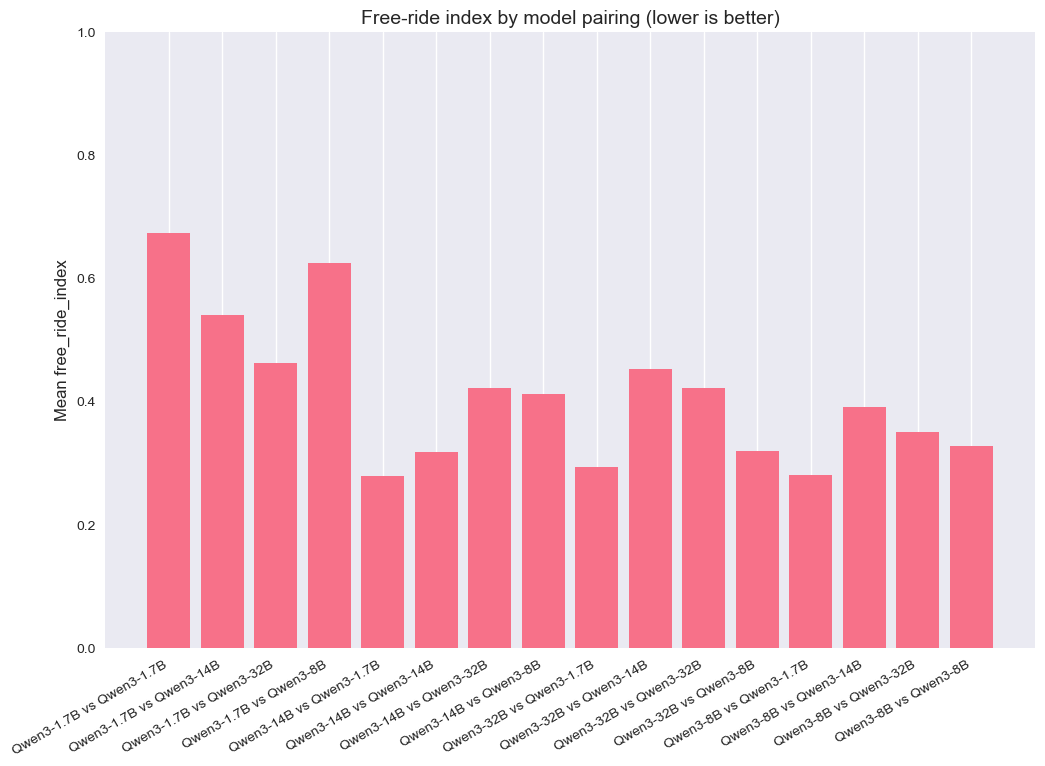

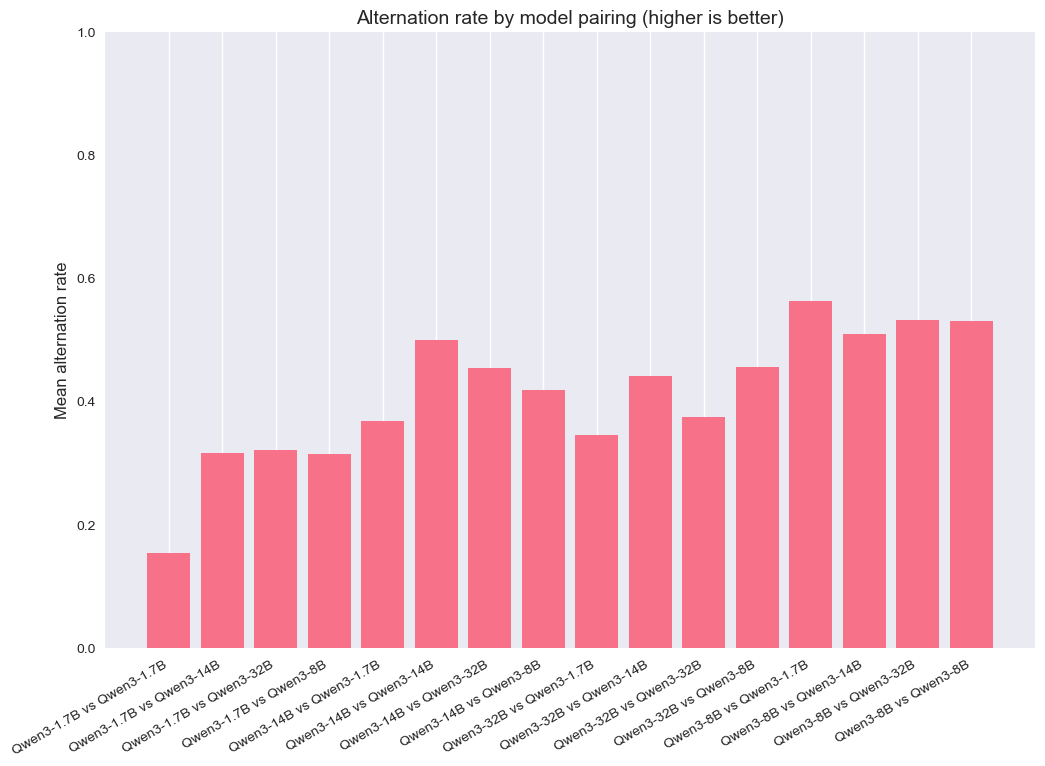

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Build base table in the same pair order as the cooperation plot if `agg` exists.
try:
    base = agg.copy()
    base["pair_label"] = (base["p0"].astype(str) + " vs " + base["p1"].astype(str))
except NameError:
    base = (
        df.groupby(["p0","p1"], dropna=False)
          .agg(mean_alternation=("alternation_rate", "mean"))
          .reset_index()
    )
    base["pair_label"] = (base["p0"].astype(str) + " vs " + base["p1"].astype(str))

# Compute mean free_ride_index per pair and merge (so ordering matches `base`)
fr = (
    df.groupby(["p0","p1"], dropna=False)["free_ride_index"]
      .mean()
      .reset_index(name="mean_free_ride")
)
base = base.merge(fr, on=["p0","p1"], how="left")

pairs = base["pair_label"].tolist()
positions = np.arange(len(pairs))

# ---- Bar: mean free_ride_index by pair ----
plt.figure()
heights = base["mean_free_ride"].clip(0, 1).fillna(0).to_numpy()
plt.bar(positions, heights)
plt.xticks(positions, pairs, rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("Mean free_ride_index")
plt.title("Free-ride index by model pairing (lower is better)")
plt.grid(axis="y")
plt.show()

# ---- Bar: mean alternation_rate by pair ----
plt.figure()
heights = base["mean_alternation"].clip(0, 1).fillna(0).to_numpy()
plt.bar(positions, heights)
plt.xticks(positions, pairs, rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("Mean alternation rate")
plt.title("Alternation rate by model pairing (higher is better)")
plt.grid(axis="y")
plt.show()


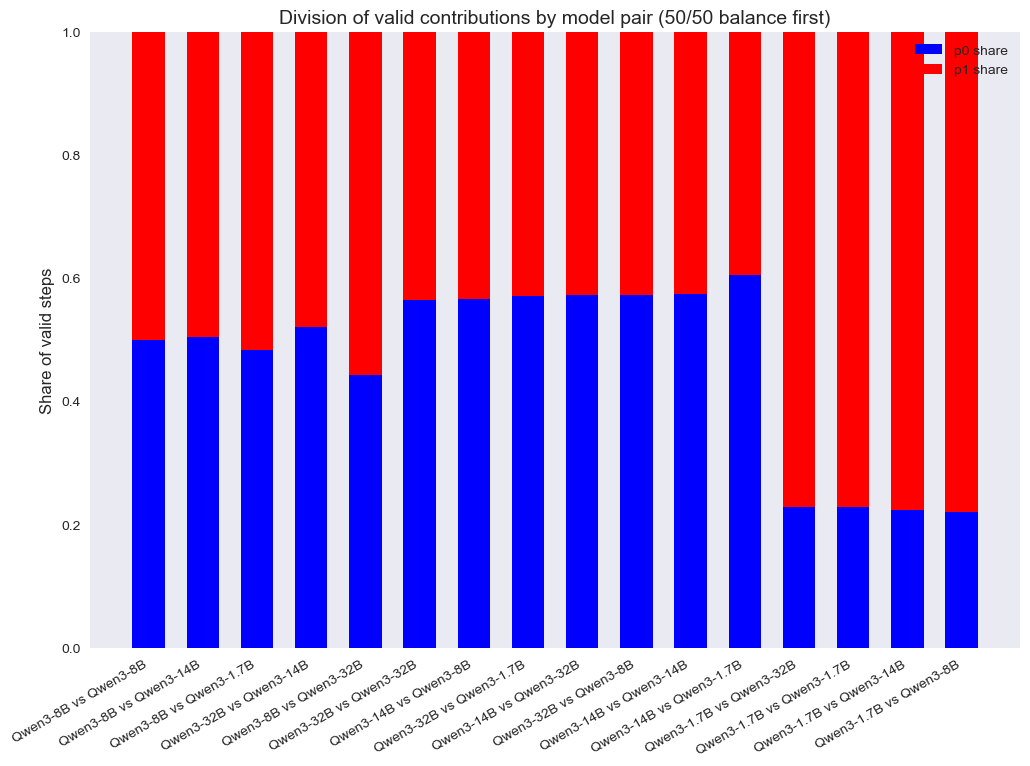

In [59]:
# Stacked bars: balance-first ordering (closest to 50/50 first)
plt.figure()
width = 0.6

pairs = (agg["p0"] + " vs " + agg["p1"]).astype(str).tolist()
p0_share = agg["p0_share_valid"].astype(float).to_numpy()
p1_share = agg["p1_share_valid"].astype(float).to_numpy()
total_valid = agg["total_valid"].fillna(0).to_numpy()

# Closeness to perfect balance (0.5)
closeness = np.abs(p0_share - 0.5)

# Push invalid/empty cases to the end
invalid = ~np.isfinite(closeness) | (total_valid == 0)
closeness[invalid] = np.inf

# Order: first by smallest closeness (50/50 first), then by larger total_valid
order = np.lexsort((-total_valid, closeness))

# Apply ordering
pairs_sorted = [pairs[i] for i in order]
p0_sorted = p0_share[order]
p1_sorted = p1_share[order]
xpos = np.arange(len(pairs_sorted))

# Plot
plt.bar(xpos, p0_sorted, width=width, label="p0 share", color="blue")
plt.bar(xpos, p1_sorted, bottom=p0_sorted, width=width, label="p1 share", color="red")
plt.xticks(xpos, pairs_sorted, rotation=30, ha="right")
plt.ylim(0, 1)
plt.ylabel("Share of valid steps")
plt.title("Division of valid contributions by model pair (50/50 balance first)")
plt.legend()
plt.grid(axis="y")
plt.show()


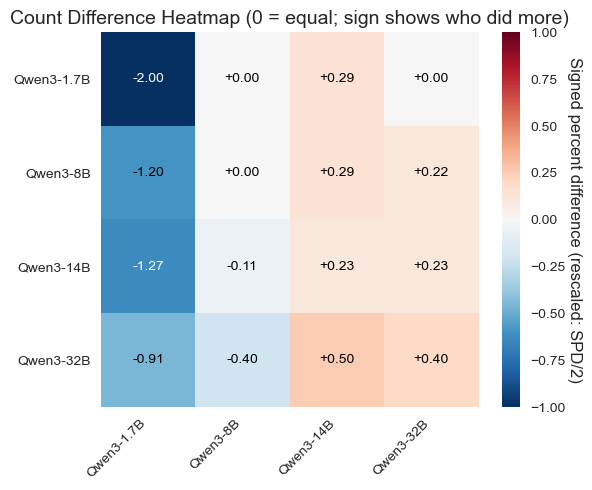

In [76]:
# Count-difference heatmap between two agents (p0 vs p1), numeric-aware ordering.
# Emphasizes whether counts are similar (near 0) or different (near 1), with optional direction.
# Requires: pandas, numpy, matplotlib  (re from stdlib)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# --- Parameters ---------------------------------------------------------------
# What to plot: "abs_percent_diff" (= |a-b|/(a+b), [0,1]),
#               "signed_percent_diff" (= 2(a-b)/(a+b), [-2,2]),
#               or "similarity" (= 1 - |a-b|/(a+b), [0,1]).
METRIC = "signed_percent_diff"

# Aggregate across runs with "mean" or "median" (median is robust to outliers).
AGG = "median"

# How to treat (a,b) = (0,0): "nan" to ignore those rows in aggregation,
#                             "equal" to treat as equal (SPD=0, diff=0, similarity=1).
ZERO_ZERO = "nan"

# --- 1) Validate input --------------------------------------------------------
required = {"p0","p1","p0_valid_actions","p1_valid_actions"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"CSV is missing required columns: {sorted(missing)}")

# --- 2) Row-wise signed and absolute percent differences ---------------------
a = df["p0_valid_actions"].astype(float).to_numpy()
b = df["p1_valid_actions"].astype(float).to_numpy()
den = a + b

with np.errstate(divide="ignore", invalid="ignore"):
    spd = 2.0 * (a - b) / den         # in [-2, 2]
if ZERO_ZERO == "nan":
    spd = np.where(den == 0, np.nan, spd)
elif ZERO_ZERO == "equal":
    spd = np.where(den == 0, 0.0, spd)
else:
    raise ValueError("ZERO_ZERO must be 'nan' or 'equal'")

# Magnitude-only difference in [0,1]; and a bounded similarity in [0,1].
diff01 = np.abs(spd) / 2.0            # = |a-b|/(a+b)
sim01  = 1.0 - diff01                 # = 1 - |a-b|/(a+b)

df["_spd"]    = spd
df["_diff01"] = diff01
df["_sim01"]  = sim01

# --- 3) Aggregate by (p0, p1) ------------------------------------------------
agg_fn = {"mean":"mean", "median":"median"}[AGG]
agg = (
    df.groupby(["p0","p1"], as_index=False)
      .agg(spd=("_spd", agg_fn),
           diff01=("_diff01", agg_fn),
           sim01=("_sim01", agg_fn),
           runs=("p0","size"))
)

# --- 4) Pivot to matrix and numeric-aware ordering ---------------------------
def _natural_key(s: str):
    return [int(t) if t.isdigit() else t.lower() for t in re.findall(r"\d+|\D+", str(s))]

models = sorted(set(df["p0"]).union(set(df["p1"])), key=_natural_key)

metric_key = {"signed_percent_diff":"spd", "abs_percent_diff":"diff01", "similarity":"sim01"}[METRIC]
heat = (
    agg.pivot(index="p1", columns="p0", values=metric_key)
       .reindex(index=models, columns=models)
)

# --- 5) Plot (one figure) -----------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

if METRIC == "signed_percent_diff":
    vmin, vmax, cmap = -1.0, 1.0, "RdBu_r"  # center at 0 (equal)
    data = np.clip(heat.values / 2.0, vmin, vmax)  # rescale SPD [-2,2] -> [-1,1] for color range
    im = ax.imshow(data, aspect="auto", cmap=cmap, interpolation="nearest", resample=False, vmin=vmin, vmax=vmax)
    cbar_label = "Signed percent difference (rescaled: SPD/2)"
    annot_fmt  = lambda v: f"{(2*v):+.2f}"  # show SPD value
else:
    # abs_percent_diff or similarity are both in [0,1]
    vmin, vmax, cmap = 0.0, 1.0, "viridis"
    data = heat.values
    im = ax.imshow(data, aspect="auto", cmap=cmap, interpolation="nearest", resample=False, vmin=vmin, vmax=vmax)
    cbar_label = "Absolute percent difference" if METRIC=="abs_percent_diff" else "Similarity (1 - diff)"

ax.set_title({
    "signed_percent_diff":"Count Difference Heatmap (0 = equal; sign shows who did more)",
    "abs_percent_diff":"Count Difference Heatmap (0 = equal, 1 = maximally different)",
    "similarity":"Action-Count Similarity Heatmap (1 = equal counts)"
}[METRIC])

ax.set_xticks(np.arange(heat.shape[1])); ax.set_yticks(np.arange(heat.shape[0]))
ax.set_xticklabels(heat.columns.tolist(), rotation=45, ha="right")
ax.set_yticklabels(heat.index.tolist())
ax.grid(False)
ax.tick_params(axis="both", length=0)

# Annotate non-NaN cells with metric values
norm, cmap_obj = im.norm, im.cmap
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        if not (isinstance(v, (float, np.floating)) and np.isnan(v)):
            # choose text color by background luminance
            color = "black"
            rgba = cmap_obj(norm(data[i, j])) if METRIC=="signed_percent_diff" else cmap_obj(norm(v))
            luminance = 0.2126*rgba[0] + 0.7152*rgba[1] + 0.0722*rgba[2]
            if luminance < 0.5:
                color = "white"
            text = annot_fmt(data[i, j]) if METRIC=="signed_percent_diff" else f"{v:.2f}"
            ax.text(j, i, text, ha="center", va="center", color=color)

cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_ylabel(cbar_label, rotation=270, labelpad=12)

fig.tight_layout()

# --- 6) Save artifacts --------------------------------------------------------
out_dir = Path("./")
(agg[["p0","p1","spd","diff01","sim01","runs"]]
 .rename(columns={"p1": "agent_p1", "p0": "agent_p0"})
 .to_csv(out_dir / "agent_pairing_count_differences.csv", index=False))

fig.savefig(out_dir / f"heatmap_count_{metric_key}.png", dpi=200, bbox_inches="tight")
plt.show()


- in relation to the chef(y axis) the assistant(x axis) took +/- N
- e.g. 32 p1 /// 1.7 p0 p0 took -0.91 actions
- e.g. 32 p1 /// 32 p0 p0 took +0.4 actions

```
Inputs and validation

Requires columns: p0, p1, p0_valid_actions, p1_valid_actions. A ValueError is raised if any are missing.

Per-row metrics (formulas and ranges)

Signed percent difference (SPD): 
SPD=2(a−b)/(a+b)∈[−2,2]
SPD=2(a−b)/(a+b)∈[−2,2]. Direction encodes who had more valid actions.

Magnitude-only difference: 
∣a−b∣/(a+b)∈[0,1]
∣a−b∣/(a+b)∈[0,1].

Similarity: 
1−∣a−b∣/(a+b)∈[0,1]
1−∣a−b∣/(a+b)∈[0,1].

The ZERO_ZERO policy controls how rows with 
(a,b)=(0,0)
(a,b)=(0,0) are handled: either treated as missing (nan) or as equal (SPD=0, diff 
=0
=0, similarity 
=1
=1).

Aggregation to agent–agent level

Rows are grouped by the agent pair (p0,p1) and aggregated via AGG ("mean" or "median"; median is more robust). The output includes spd, diff01, sim01, and runs (row count contributing to that cell).

Matrix construction and ordering

The union of all agent names appearing as p0 or p1 is sorted using a natural (numeric-aware) key, ensuring intuitive ordering.

The selected METRIC ("signed_percent_diff", "abs_percent_diff", or "similarity") is pivoted to a square matrix with rows = p1 and columns = p0, reindexed to the same ordered agent list on both axes.

Visualization

A single heatmap is drawn:

If METRIC=="signed_percent_diff", a diverging colormap (RdBu_r) centered at 0 is used. Internally, SPD is rescaled by 1/2 so the color range is 
[−1,1]
[−1,1]; annotations display the original SPD values (±2.00 bounds).

Otherwise (abs_percent_diff or similarity), a sequential colormap (viridis, range 
[0,1]
[0,1]) is used.

All cells are annotated numerically; text color is switched to white/black based on background luminance for legibility.

Axes tick labels show agent names with a 45° rotation on x for readability; no grid or tick marks.

Artifacts written

agent_pairing_count_differences.csv: per-pair aggregates (agent_p0, agent_p1, spd, diff01, sim01, runs).

heatmap_count_{metric}.png: the rendered heatmap image.

The figure is also shown interactively.

How to interpret

Values near 0 (for SPD or abs-diff) or near 1 (for similarity) indicate the agents produced similar counts.

Larger magnitudes indicate greater disagreement in counts.

For SPD, the sign indicates direction (which agent tended to have more); consult the colorbar for the mapping between hue and sign.

This design makes it straightforward to see, at a glance, which agent pairs behave similarly, which diverge, and—optionally—who tends to produce more valid actions.
```
